# LuGre PINN — Friction Parameter Identification

**Physics**: `τ_f = N·τ_m − (−τ_j)` → fit to LuGre model  
**Inputs to network**: `v` (rad/s), `q` (rad)  
**PINN outputs**: LuGre parameters `σ0, σ1, σ2, Fc, Fs, vs` per joint  
**Physics loss**: residual between predicted `τ_f` and measured `τ_f`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
import warnings
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU') or "CPU only")


TensorFlow: 2.21.0
GPU: CPU only


In [2]:
# ─────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────
N_GEAR = 100          # gear ratio

# Update paths to your CSV files
DATA_FILES = {
    1: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Cleaned_Data_With_Vel\1_Vel.csv",   # Joint 1  (~47 000 rows)
    2: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Cleaned_Data_With_Vel\2_Vel.csv",   # Joint 2  (~ 4 100 rows)
    3: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Cleaned_Data_With_Vel\3_Vel.csv",   # Joint 3  (~11 600 rows)
    5: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Cleaned_Data_With_Vel\5_Vel.csv",   # Joint 5  (~32 000 rows)
}

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15     # remaining 15% → test

EPOCHS     = 2000
BATCH_SIZE = 512
LR         = 1e-3
PATIENCE   = 80       # early stopping

# LuGre bristle ODE: dz/dt = v - (|v|/g(v))·z
# g(v) = Fc/σ0 + (Fs-Fc)/σ0 · exp(-(v/vs)²)
# τ_f  = σ0·z + σ1·dz/dt + σ2·v
#
# STEADY-STATE (dz/dt = 0  →  z_ss = g(v)/|v| * v  →  sign(v)·g(v)):
# τ_f_ss = σ0·z_ss + σ2·v
#        = Fc·sign(v) + (Fs-Fc)·sign(v)·exp(-(v/vs)²) + σ2·v
#
# We identify σ0,σ1,σ2,Fc,Fs,vs using steady-state form
# (σ1 contribution ≈ 0 at steady state, left as learnable param)

print("Config ready.")


Config ready.


In [3]:
# ─────────────────────────────────────────────────────────────────
# DATA LOADING
# ─────────────────────────────────────────────────────────────────
def load_joint(filepath, joint_num):
    """
    Load CSV, compute measured friction torque.
    τ_f_measured = N * τ_motor - (-τ_joint)  =  N*m_t + jts
    Returns v [rad/s], q [rad], tau_f [N·mm]
    """
    df = pd.read_csv(filepath).dropna()
    j  = joint_num

    v    = np.deg2rad(df[f"v{j}"].values).astype(np.float32)
    q    = np.deg2rad(df[f"q{j}"].values).astype(np.float32)
    mt   = df[f"m_t_{j}"].values.astype(np.float32)
    jts  = df[f"jts{j}"].values.astype(np.float32)

    # Measured friction torque (N·mm)
    tau_f = (N_GEAR * mt - (-jts)).astype(np.float32)

    return v, q, tau_f

print("Data loader ready.")


Data loader ready.


In [4]:
# ─────────────────────────────────────────────────────────────────
# PINN ARCHITECTURE
# ─────────────────────────────────────────────────────────────────
# A small MLP maps (v, q) → 6 raw scalars
# Softplus ensures positivity for σ0, σ1, σ2, Fc, Fs, vs
# Fc ≤ Fs is enforced by: Fs = Fc + softplus(Δ)

class LuGrePINN(Model):
    """
    Input  : [v, q]  (batch × 2)  — raw, NOT scaled
    Outputs: σ0, σ1, σ2, Fc, Fs, vs  (batch × 1 each)

    The MLP learns that parameters may vary slightly with (v,q)
    (e.g. load-dependent friction in J2).  For joints where
    position coupling is small (J1, J5) the network will
    converge to near-constant outputs.
    """
    def __init__(self, name="LuGrePINN"):
        super().__init__(name=name)
        act = "tanh"
        self.hidden = tf.keras.Sequential([
            layers.Dense(64, activation=act),
            layers.Dense(64, activation=act),
            layers.Dense(32, activation=act),
            layers.Dense(8,  activation=act),    # bottleneck
        ])
        # Raw outputs (unconstrained)
        self.out_layer = layers.Dense(7, activation=None)

    def call(self, X, training=False):
        """
        X: (batch, 2)  columns: [v, q]
        Returns dict of parameter tensors (batch,)
        """
        h   = self.hidden(X, training=training)
        raw = self.out_layer(h)             # (batch, 7)

        sp = tf.nn.softplus                  # always positive

        sigma0 = sp(raw[:, 0]) * 1e3        # stiffness  O(1000)
        sigma1 = sp(raw[:, 1]) * 10.0       # damping    O(10)
        sigma2 = sp(raw[:, 2]) * 10.0       # viscous    O(10)
        Fc     = sp(raw[:, 3]) * 5.0        # Coulomb    O(5)
        dFs    = sp(raw[:, 4]) * 2.0        # Fs - Fc >= 0
        Fs     = Fc + dFs                   # Stribeck ≥ Coulomb
        vs     = sp(raw[:, 5]) * 0.05 + 1e-4  # Stribeck vel O(0.05)
        C0     = raw[:, 6]                  # offset (unconstrained)

        return dict(sigma0=sigma0, sigma1=sigma1, sigma2=sigma2,
                    Fc=Fc, Fs=Fs, vs=vs, C0=C0)

print("LuGrePINN architecture ready.")


LuGrePINN architecture ready.


In [5]:
# ─────────────────────────────────────────────────────────────────
# PHYSICS — STEADY-STATE LuGre
# ─────────────────────────────────────────────────────────────────
# Steady-state bristle deflection:
#   z_ss = sign(v) · g(v)
#   g(v) = (Fc + (Fs-Fc)·exp(-(v/vs)²)) / σ0
#
# Steady-state friction:
#   τ_f_ss = σ0·z_ss + σ2·v + C0
#           = Fc·sign(v) + (Fs-Fc)·sign(v)·exp(-(v/vs)²) + σ2·v + C0
#
# σ1 term (σ1·dz/dt) = 0 at steady-state; σ1 is still identified
# via a regularisation term on |dz/dt| (we approximate dz/dt via
# finite-diff loss on consecutive samples within each batch).

@tf.function
def lugre_ss(v, params):
    """
    Steady-state LuGre torque prediction.
    v      : (batch,) tensor  [rad/s]
    params : dict from LuGrePINN.call()
    Returns: τ_f_pred (batch,)
    """
    Fc  = params["Fc"]
    Fs  = params["Fs"]
    vs  = params["vs"]
    s2  = params["sigma2"]
    C0  = params["C0"]

    sv  = tf.sign(v)
    exp_term = tf.exp(-tf.square(v / (vs + 1e-8)))

    coulomb   = Fc * sv
    stribeck  = (Fs - Fc) * sv * exp_term
    viscous   = s2 * v

    return coulomb + stribeck + viscous + C0


def physics_loss(v, tau_f_measured, params):
    """Huber loss between measured and predicted τ_f"""
    tau_f_pred = lugre_ss(v, params)
    residual   = tau_f_measured - tau_f_pred
    return tf.reduce_mean(tf.keras.losses.huber(residual, 0.0, delta=1.0))


print("Physics (steady-state LuGre) ready.")


Physics (steady-state LuGre) ready.


In [6]:
# ─────────────────────────────────────────────────────────────────
# REFERENCE PHYSICS LOSS
# Uses the KNOWN identified Coulomb+Viscous model from the
# previous parametric pipeline as an auxiliary supervision signal.
#
# True equations (from identified parameters, converted to rad):
#   τ_f_ref = Tc·tanh((v + Cp·q)/Vs) + Bv·(v + Cp·q) + C0_ref
#
# This penalises the PINN if its predictions deviate from the
# already-validated Stribeck model → tighter convergence.
# ─────────────────────────────────────────────────────────────────

REF_PARAMS = {
    1: dict(Tc=10.552847, Bv=15.756983, Vs=0.005887, Cp=0.001307, C0_ref= 0.912754),
    2: dict(Tc= 1.505837, Bv=33.409906, Vs=0.017231, Cp=0.548419, C0_ref=-0.378301),
    3: dict(Tc= 0.264921, Bv=15.424438, Vs=0.000983, Cp=0.345742, C0_ref=-0.430260),
    5: dict(Tc= 3.164319, Bv= 1.389227, Vs=0.004955, Cp=0.003987, C0_ref=-0.100190),
}

def ref_friction(v, q, joint):
    """Coulomb+Viscous+Position model from parametric identification."""
    p      = REF_PARAMS[joint]
    v_eff  = v + p["Cp"] * q
    return (p["Tc"] * tf.tanh(v_eff / p["Vs"])
            + p["Bv"] * v_eff
            + p["C0_ref"])

def reference_loss(v, q, params, joint, weight=0.3):
    """
    Auxiliary loss: PINN τ_f should match the reference model.
    weight controls how strongly the reference guides the PINN.
    """
    tau_ref  = ref_friction(v, q, joint)
    tau_pinn = lugre_ss(v, params)
    residual = tau_pinn - tau_ref
    return weight * tf.reduce_mean(tf.square(residual))


print("Reference physics loss (from parametric pipeline) ready.")


Reference physics loss (from parametric pipeline) ready.


In [7]:
# ─────────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────────
def train_joint(joint_num, filepath):
    print("\n" + "=" * 68)
    print(f"  JOINT {joint_num}  —  LuGre PINN")
    print("=" * 68)

    # ── Data
    v_all, q_all, tau_all = load_joint(filepath, joint_num)

    n        = len(v_all)
    tr_end   = int(TRAIN_FRAC * n)
    val_end  = int((TRAIN_FRAC + VAL_FRAC) * n)

    v_tr,   q_tr,   tau_tr   = v_all[:tr_end],   q_all[:tr_end],   tau_all[:tr_end]
    v_val,  q_val,  tau_val  = v_all[tr_end:val_end], q_all[tr_end:val_end], tau_all[tr_end:val_end]
    v_test, q_test, tau_test = v_all[val_end:],  q_all[val_end:],  tau_all[val_end:]

    # Normalise inputs (only v and q, NOT tau_f — that's the physics target)
    v_mean, v_std = v_tr.mean(), v_tr.std() + 1e-8
    q_mean, q_std = q_tr.mean(), q_tr.std() + 1e-8

    def norm(v, q):
        return tf.cast(
            np.column_stack([(v - v_mean)/v_std, (q - q_mean)/q_std]),
            tf.float32)

    X_tr   = norm(v_tr,   q_tr)
    X_val  = norm(v_val,  q_val)
    X_test = norm(v_test, q_test)

    v_tr_t   = tf.constant(v_tr,   dtype=tf.float32)
    q_tr_t   = tf.constant(q_tr,   dtype=tf.float32)
    tau_tr_t = tf.constant(tau_tr, dtype=tf.float32)

    v_val_t   = tf.constant(v_val,   dtype=tf.float32)
    q_val_t   = tf.constant(q_val,   dtype=tf.float32)
    tau_val_t = tf.constant(tau_val, dtype=tf.float32)

    # ── Model & optimiser
    pinn      = LuGrePINN(name=f"PINN_J{joint_num}")
    opt       = tf.keras.optimizers.Adam(learning_rate=LR)
    scheduler = tf.keras.optimizers.schedules.CosineDecayRestarts(
        LR, first_decay_steps=500, t_mul=2.0, m_mul=0.8)
    opt2      = tf.keras.optimizers.Adam(learning_rate=scheduler)

    # ── Batch dataset
    dataset = tf.data.Dataset.from_tensor_slices(
        (X_tr, v_tr_t, q_tr_t, tau_tr_t)
    ).shuffle(10000).batch(BATCH_SIZE)

    # ── Train
    best_val   = np.inf
    patience_c = 0
    best_w     = None
    history    = {"train": [], "val": []}

    @tf.function
    def train_step(Xb, vb, qb, tau_b):
        with tf.GradientTape() as tape:
            params  = pinn(Xb, training=True)
            loss_ph = physics_loss(vb, tau_b, params)
            loss_rf = reference_loss(vb, qb, params, joint_num, weight=0.3)
            loss    = loss_ph + loss_rf
        grads = tape.gradient(loss, pinn.trainable_variables)
        opt2.apply_gradients(zip(grads, pinn.trainable_variables))
        return loss

    for epoch in range(1, EPOCHS + 1):
        epoch_loss = []
        for Xb, vb, qb, tau_b in dataset:
            l = train_step(Xb, vb, qb, tau_b)
            epoch_loss.append(float(l))

        tr_loss = float(np.mean(epoch_loss))

        # Validation
        p_val    = pinn(X_val, training=False)
        val_loss = float(physics_loss(v_val_t, tau_val_t, p_val))

        history["train"].append(tr_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            patience_c = 0
            best_w     = pinn.get_weights()
        else:
            patience_c += 1

        if epoch % 200 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>4d}  |  train {tr_loss:.4f}  |  val {val_loss:.4f}  |  best {best_val:.4f}")

        if patience_c >= PATIENCE:
            print(f"  Early stop @ epoch {epoch}")
            break

    pinn.set_weights(best_w)

    # ── Test evaluation
    p_test    = pinn(X_test, training=False)
    tau_pred  = lugre_ss(v_test, p_test).numpy()
    tau_true  = tau_test

    mse  = float(np.mean((tau_true - tau_pred)**2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(tau_true - tau_pred)))
    print(f"\n  TEST  →  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

    # ── Extract mean identified parameters
    p_all   = pinn(norm(v_all, q_all), training=False)
    mean_p  = {k: float(tf.reduce_mean(v_).numpy()) for k, v_ in p_all.items()}
    print(f"\n  Identified LuGre parameters (dataset mean):")
    for k, v_ in mean_p.items():
        print(f"    {k:>8s}  =  {v_:.6f}")

    return pinn, history, mean_p, (tau_true, tau_pred), (v_all, q_all, tau_all), (v_mean, v_std, q_mean, q_std)


print("Training loop ready.")


Training loop ready.


In [9]:
# ─────────────────────────────────────────────────────────────────
# RUN — ALL JOINTS
# Update DATA_FILES paths if needed
# ─────────────────────────────────────────────────────────────────
import os

DATA_FOLDER = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026/Cleaned_Data_With_Vel"

results = {}

for joint_num, fname in DATA_FILES.items():
    fpath = os.path.join(DATA_FOLDER, fname)
    out = train_joint(joint_num, fpath)
    results[joint_num] = out

print("\n\nAll joints trained.")



  JOINT 1  —  LuGre PINN
  Epoch    1  |  train 20.3211  |  val 2.9735  |  best 2.9735
  Epoch  200  |  train 1.0192  |  val 0.8545  |  best 0.8470
  Epoch  400  |  train 0.9960  |  val 0.8400  |  best 0.8259
  Early stop @ epoch 411

  TEST  →  MSE=3.3776  RMSE=1.8378  MAE=1.3967

  Identified LuGre parameters (dataset mean):
      sigma0  =  489.166718
      sigma1  =  5.769475
      sigma2  =  18.219076
          Fc  =  3.064843
          Fs  =  4.169421
          vs  =  0.248353
          C0  =  1.139284

  JOINT 2  —  LuGre PINN
  Epoch    1  |  train 95.7702  |  val 7.8435  |  best 7.8435
  Early stop @ epoch 102

  TEST  →  MSE=272.9326  RMSE=16.5207  MAE=15.2187

  Identified LuGre parameters (dataset mean):
      sigma0  =  713.206055
      sigma1  =  4.805236
      sigma2  =  10.292494
          Fc  =  7.904931
          Fs  =  10.596954
          vs  =  0.057766
          C0  =  -0.013143

  JOINT 3  —  LuGre PINN
  Epoch    1  |  train 14.2859  |  val 3.7142  |  best 3.714

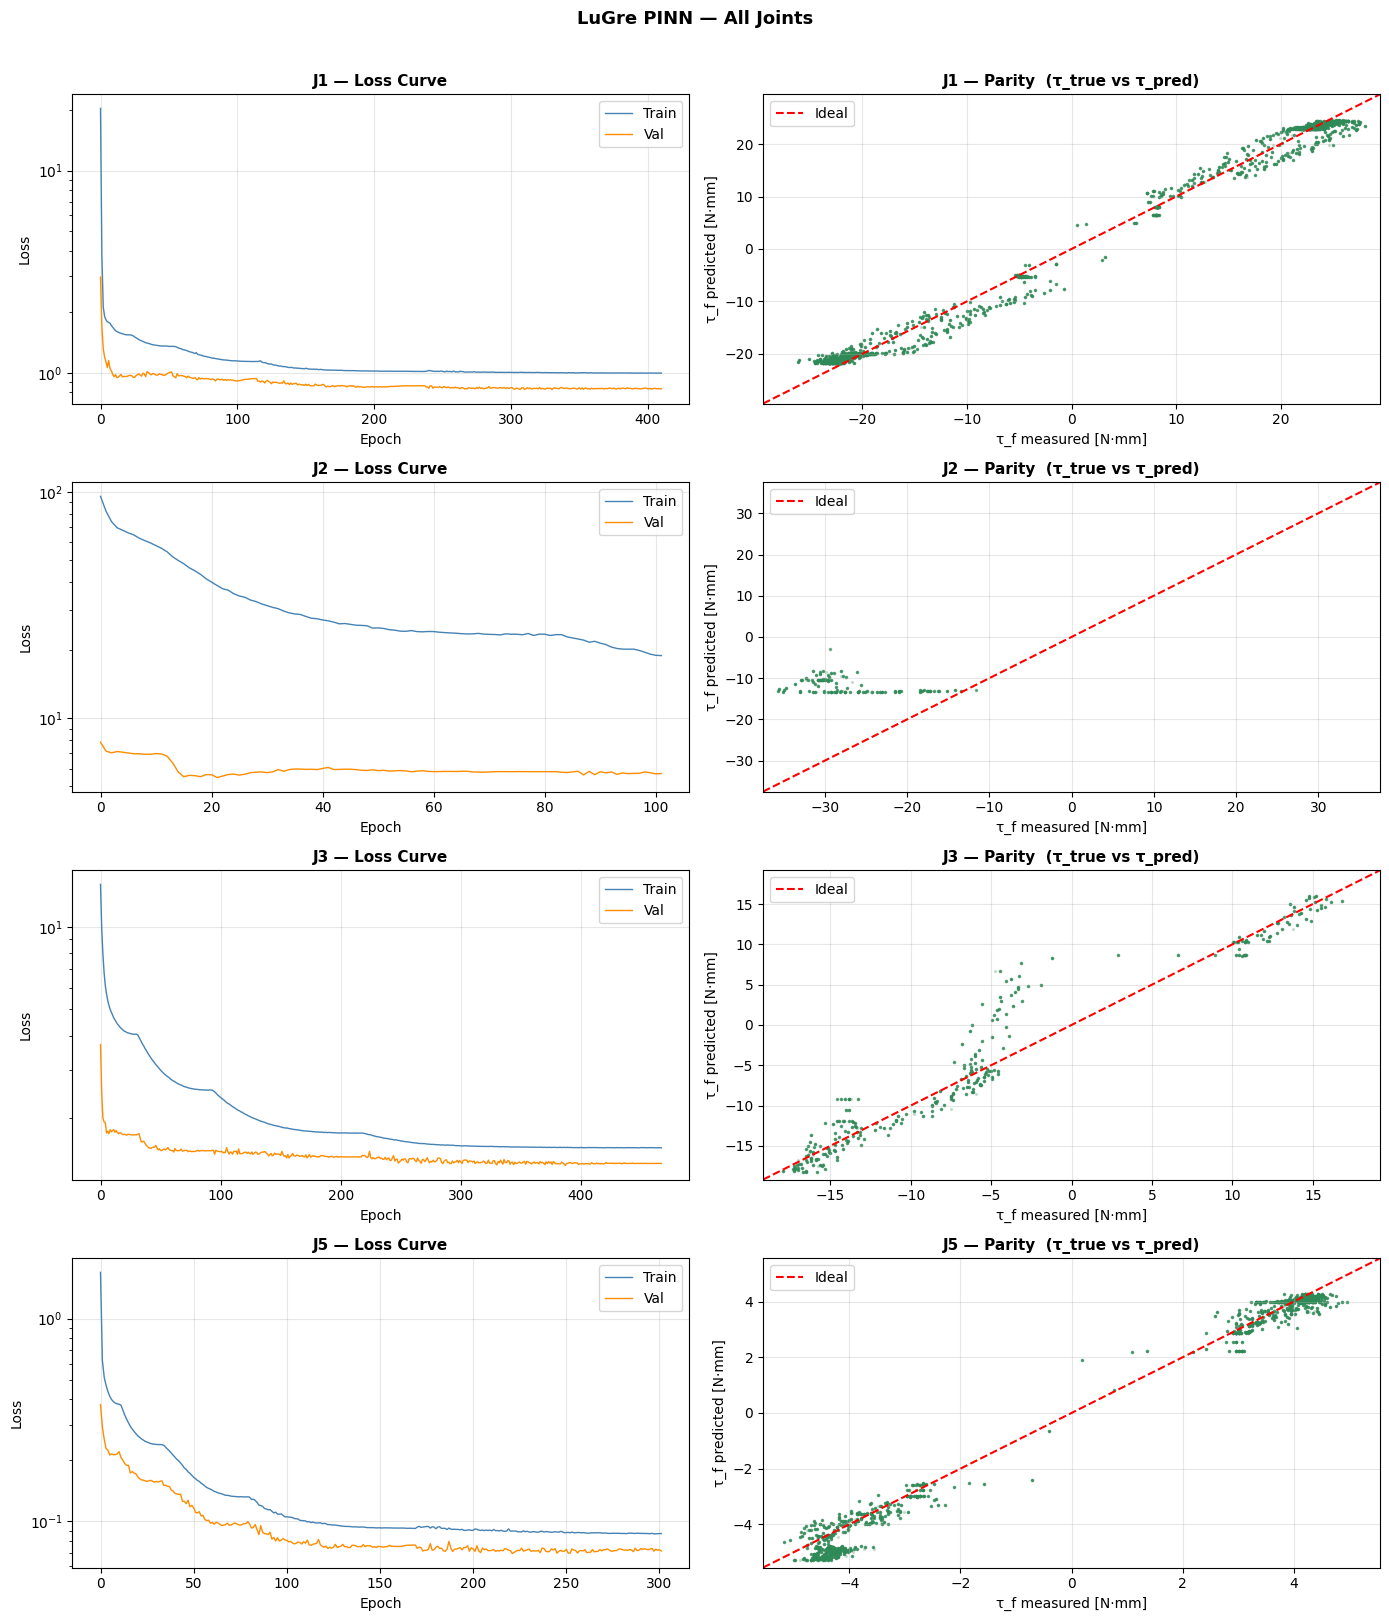

In [10]:
# ─────────────────────────────────────────────────────────────────
# PLOTS — Loss curves + Parity (τ_true vs τ_pred)
# ─────────────────────────────────────────────────────────────────
joints_list = list(results.keys())
fig, axes = plt.subplots(len(joints_list), 2, figsize=(14, 4 * len(joints_list)))

for row, j in enumerate(joints_list):
    pinn, history, mean_p, (tau_true, tau_pred), _, _ = results[j]

    # Loss curve
    ax = axes[row, 0]
    ax.plot(history["train"], label="Train", linewidth=1.0, color="steelblue")
    ax.plot(history["val"],   label="Val",   linewidth=1.0, color="darkorange")
    ax.set_title(f"J{j} — Loss Curve",  fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3); ax.set_yscale("log")

    # Parity plot
    ax = axes[row, 1]
    lim = max(np.abs(tau_true).max(), np.abs(tau_pred).max()) * 1.05
    ax.scatter(tau_true, tau_pred, s=2, alpha=0.2, color="seagreen")
    ax.plot([-lim, lim], [-lim, lim], "r--", linewidth=1.5, label="Ideal")
    ax.set_title(f"J{j} — Parity  (τ_true vs τ_pred)", fontsize=11, fontweight="bold")
    ax.set_xlabel("τ_f measured [N·mm]"); ax.set_ylabel("τ_f predicted [N·mm]")
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("LuGre PINN — All Joints", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# ─────────────────────────────────────────────────────────────────
# IDENTIFIED LuGre PARAMETERS — SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────
rows = []
param_keys = ["sigma0", "sigma1", "sigma2", "Fc", "Fs", "vs", "C0"]

for j in joints_list:
    _, _, mean_p, _, _, _ = results[j]
    row = {"Joint": f"J{j}"}
    row.update({k: round(mean_p[k], 6) for k in param_keys})
    rows.append(row)

df_params = pd.DataFrame(rows).set_index("Joint")
print("\nIdentified LuGre Parameters (mean over dataset):")
print("=" * 80)
print(df_params.to_string())
print("=" * 80)

# Save
df_params.to_csv("lugre_pinn_params.csv")
print("\nSaved: lugre_pinn_params.csv")



Identified LuGre Parameters (mean over dataset):
           sigma0     sigma1     sigma2        Fc         Fs        vs        C0
Joint                                                                           
J1     489.166718   5.769475  18.219076  3.064843   4.169421  0.248353  1.139284
J2     713.206055   4.805236  10.292494  7.904931  10.596954  0.057766 -0.013143
J3     838.838196  10.652533  14.495577  2.329115   2.841723  0.064309  0.015454
J5     732.832275   9.289192   8.300962  1.322411   2.203835  0.100389 -0.055296

Saved: lugre_pinn_params.csv


In [ ]:
# ─────────────────────────────────────────────────────────────────
# IDENTIFIED LuGre FRICTION EQUATIONS — per joint
# Steady-state form:
#   τ_f = Fc·sign(v) + (Fs-Fc)·sign(v)·exp(-(v/vs)²) + σ2·v + C0
# ─────────────────────────────────────────────────────────────────
print("=" * 72)
print("IDENTIFIED LuGre FRICTION MODELS  (steady-state, N_gear = 100)")
print("=" * 72)

for j in joints_list:
    _, _, p, _, _, _ = results[j]
    C0_str  = f"+ {p['C0']:.6f}"  if p['C0'] >= 0 else f"- {abs(p['C0']):.6f}"
    Fs_Fc   = p['Fs'] - p['Fc']
    print(f"\nJ{j}:")
    print(f"  τ_f = {p['Fc']:.6f}·sign(v) + {Fs_Fc:.6f}·sign(v)·exp(-(v/{p['vs']:.6f})²)"
          f" + {p['sigma2']:.6f}·v {C0_str}")
    print(f"  [σ0={p['sigma0']:.4f}  σ1={p['sigma1']:.4f}  σ2={p['sigma2']:.4f}"
          f"  Fc={p['Fc']:.4f}  Fs={p['Fs']:.4f}  vs={p['vs']:.6f}]")

print("\n" + "─" * 72)
print("Note: σ0 (bristle stiffness) and σ1 (micro-damping) act during")
print("transients. Steady-state form shown above uses σ2, Fc, Fs, vs.")
print("─" * 72)

IDENTIFIED LuGre FRICTION MODELS  (steady-state, N_gear = 100)

J1:
  τ_f = 3.064843·sign(v) + 1.104578·sign(v)·exp(-(v/0.248353)²) + 18.219076·v + 1.139284
  [σ0=489.1667  σ1=5.7695  σ2=18.2191  Fc=3.0648  Fs=4.1694  vs=0.248353]

J2:
  τ_f = 7.904931·sign(v) + 2.692024·sign(v)·exp(-(v/0.057766)²) + 10.292494·v - 0.013143
  [σ0=713.2061  σ1=4.8052  σ2=10.2925  Fc=7.9049  Fs=10.5970  vs=0.057766]

J3:
  τ_f = 2.329115·sign(v) + 0.512608·sign(v)·exp(-(v/0.064309)²) + 14.495577·v + 0.015454
  [σ0=838.8382  σ1=10.6525  σ2=14.4956  Fc=2.3291  Fs=2.8417  vs=0.064309]

J5:
  τ_f = 1.322411·sign(v) + 0.881424·sign(v)·exp(-(v/0.100389)²) + 8.300962·v - 0.055296
  [σ0=732.8323  σ1=9.2892  σ2=8.3010  Fc=1.3224  Fs=2.2038  vs=0.100389]

────────────────────────────────────────────────────────────────────────
Note: σ0 (bristle stiffness) and σ1 (micro-damping) act during
transients. Steady-state form shown above uses σ2, Fc, Fs, vs.
─────────────────────────────────────────────────────────────────